Project Title

Customer Segmentation Using DBSCAN Clustering: A Density-Based Machine Learning Approach

Business Problem

A bank wants to understand the spending behavior of its credit card customers. Instead of manually grouping customers, the bank wants to discover natural customer segments and identify unusual customers (outliers) for personalized marketing and fraud monitoring.

Since there are no predefined labels, we will use **DBSCAN**, an unsupervised machine learning algorithm that groups customers based on density and automatically detects noise points.


Dataset: Credit Card Dataset for Clustering

Features

| Feature                          | Description                    |
| -------------------------------- | ------------------------------ |
| BALANCE                          | Account balance                |
| BALANCE_FREQUENCY                | Balance update frequency       |
| PURCHASES                        | Purchase amount                |
| ONEOFF_PURCHASES                 | One-time purchases             |
| INSTALLMENTS_PURCHASES           | Installment purchases          |
| CASH_ADVANCE                     | Cash advance amount            |
| PURCHASES_FREQUENCY              | Purchase frequency             |
| ONEOFF_PURCHASES_FREQUENCY       | One-off purchase frequency     |
| PURCHASES_INSTALLMENTS_FREQUENCY | Installment purchase frequency |
| CASH_ADVANCE_FREQUENCY           | Cash advance frequency         |
| CASH_ADVANCE_TRX                 | Cash advance transactions      |
| PURCHASES_TRX                    | Purchase transactions          |
| CREDIT_LIMIT                     | Credit limit                   |
| PAYMENTS                         | Total payments                 |
| MINIMUM_PAYMENTS                 | Minimum payments               |
| PRC_FULL_PAYMENT                 | Percentage of full payment     |
| TENURE                           | Card tenure                    |

Target

None (Unsupervised Learning)

# Learning Objectives


* What is Unsupervised Learning
* What is Density-Based Clustering
* Core Points
* Border Points
* Noise Points
* Feature Scaling
* PCA
* K-distance Graph
* Choosing eps
* Choosing min_samples
* Cluster Visualization
* Outlier Detection
* Silhouette Score
* Cluster Profiling
* Business Interpretation

What is Clustering?

Clustering is an **unsupervised machine learning technique** that groups similar data points together without using predefined labels. Unlike classification, clustering discovers hidden structures and relationships within the data.

Businesses use clustering for:

* Customer Segmentation
* Fraud Detection
* Market Basket Analysis
* Medical Research
* Image Segmentation
* Recommendation Systems
* Network Intrusion Detection



What is DBSCAN?

DBSCAN stands for **Density-Based Spatial Clustering of Applications with Noise**.

Instead of assuming a fixed number of clusters like K-Means, DBSCAN identifies clusters based on the density of data points. It also automatically detects outliers (noise), making it ideal for real-world datasets with irregular cluster shapes and anomalies.


 Key Concepts

  Core Point

A point that has at least **min_samples** neighbors within a radius (**eps**).

 Border Point

A point that has fewer than **min_samples** neighbors but lies within the neighborhood of a core point.

Noise Point (Outlier)

A point that is neither a core point nor reachable from any core point. These are labeled as **-1** by DBSCAN.


Advantages of DBSCAN

* No need to specify the number of clusters in advance.
* Can discover clusters of arbitrary shapes.
* Automatically identifies outliers.
* Performs well on spatial and density-based datasets.
* Robust to noise.





Limitations

* Sensitive to the choice of `eps` and `min_samples`.
* Performance decreases on datasets with varying densities.
* Distance calculations become less effective in very high-dimensional data.




## Workflow

```text
Load Dataset
      │
      ▼
EDA
      │
      ▼
Data Cleaning
      │
      ▼
Feature Scaling
      │
      ▼
K-Distance Graph
      │
      ▼
Select eps
      │
      ▼
Train DBSCAN
      │
      ▼
Cluster Evaluation
      │
      ▼
Visualization
      │
      ▼
Business Insights
```

---


In [55]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import DBSCAN

from sklearn.neighbors import NearestNeighbors

from sklearn.decomposition import PCA

from sklearn.metrics import silhouette_score

In [56]:
df = pd.read_csv("CC GENERAL.csv")

In [57]:
df.head().style.background_gradient('coolwarm')

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.400000,0.000000,95.400000,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.000000,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.000000,0.000000,0.000000,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.000000,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.170000,773.170000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.000000,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.000000,1499.000000,0.000000,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.000000,0.000000,nan,0.000000,12
4,C10005,817.714335,1.000000,16.000000,16.000000,0.000000,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.000000,678.334763,244.791237,0.000000,12


In [58]:
df.tail().style.background_gradient('coolwarm')

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
8945,C19186,28.493517,1.000000,291.120000,0.000000,291.120000,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.000000,325.594462,48.886365,0.500000,6
8946,C19187,19.183215,1.000000,300.000000,0.000000,300.000000,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.000000,275.861322,nan,0.000000,6
8947,C19188,23.398673,0.833333,144.400000,0.000000,144.400000,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.000000,81.270775,82.418369,0.250000,6
8948,C19189,13.457564,0.833333,0.000000,0.000000,0.000000,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.000000,52.549959,55.755628,0.250000,6
8949,C19190,372.708075,0.666667,1093.250000,1093.250000,0.000000,127.040008,0.666667,0.666667,0.000000,0.333333,2,23,1200.000000,63.165404,88.288956,0.000000,6


In [59]:
df.shape

(8950, 18)

In [60]:
df.columns

Index(['CUST_ID', 'BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES',
       'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE',
       'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY',
       'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY',
       'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS',
       'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE'],
      dtype='object')

In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [62]:
df.dtypes

CUST_ID                              object
BALANCE                             float64
BALANCE_FREQUENCY                   float64
PURCHASES                           float64
ONEOFF_PURCHASES                    float64
INSTALLMENTS_PURCHASES              float64
CASH_ADVANCE                        float64
PURCHASES_FREQUENCY                 float64
ONEOFF_PURCHASES_FREQUENCY          float64
PURCHASES_INSTALLMENTS_FREQUENCY    float64
CASH_ADVANCE_FREQUENCY              float64
CASH_ADVANCE_TRX                      int64
PURCHASES_TRX                         int64
CREDIT_LIMIT                        float64
PAYMENTS                            float64
MINIMUM_PAYMENTS                    float64
PRC_FULL_PAYMENT                    float64
TENURE                                int64
dtype: object

In [63]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,1564.474828,2081.531879,0.000000,128.281915,873.385231,2054.140036,19043.13856
BALANCE_FREQUENCY,8950.0,0.877271,0.236904,0.000000,0.888889,1.000000,1.000000,1.00000
PURCHASES,8950.0,1003.204834,2136.634782,0.000000,39.635000,361.280000,1110.130000,49039.57000
ONEOFF_PURCHASES,8950.0,592.437371,1659.887917,0.000000,0.000000,38.000000,577.405000,40761.25000
INSTALLMENTS_PURCHASES,8950.0,411.067645,904.338115,0.000000,0.000000,89.000000,468.637500,22500.00000
CASH_ADVANCE,8950.0,978.871112,2097.163877,0.000000,0.000000,0.000000,1113.821139,47137.21176
PURCHASES_FREQUENCY,8950.0,0.490351,0.401371,0.000000,0.083333,0.500000,0.916667,1.00000
ONEOFF_PURCHASES_FREQUENCY,8950.0,0.202458,0.298336,0.000000,0.000000,0.083333,0.300000,1.00000
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,0.364437,0.397448,0.000000,0.000000,0.166667,0.750000,1.00000
CASH_ADVANCE_FREQUENCY,8950.0,0.135144,0.200121,0.000000,0.000000,0.000000,0.222222,1.50000


This table provides the count, mean, standard deviation, minimum, quartiles, and maximum for each numerical feature. examine the scale and spread of each variable to understand why feature scaling will be necessary before applying DBSCAN.

5. Exploratory Data Analysis (EDA)

Before building a clustering model, we need to understand the structure of the dataset, identify missing values, detect duplicates, and explore the distribution of each feature.

Check Missing Values

In [64]:
missing_values = df.isnull().sum()

missing_df = pd.DataFrame({

    "Feature": missing_values.index,

    "Missing Values": missing_values.values,
    
    "Percentage": (missing_values.values/len(df))*100
})

missing_df.sort_values("Missing Values", ascending=False)

,Feature,Missing Values,Percentage
15,MINIMUM_PAYMENTS,313,3.497207
13,CREDIT_LIMIT,1,0.011173
0,CUST_ID,0,0.000000
1,BALANCE,0,0.000000
16,PRC_FULL_PAYMENT,0,0.000000
14,PAYMENTS,0,0.000000
12,PURCHASES_TRX,0,0.000000
11,CASH_ADVANCE_TRX,0,0.000000
10,CASH_ADVANCE_FREQUENCY,0,0.000000
9,PURCHASES_INSTALLMENTS_FREQUENCY,0,0.000000


Visualize Missing Values

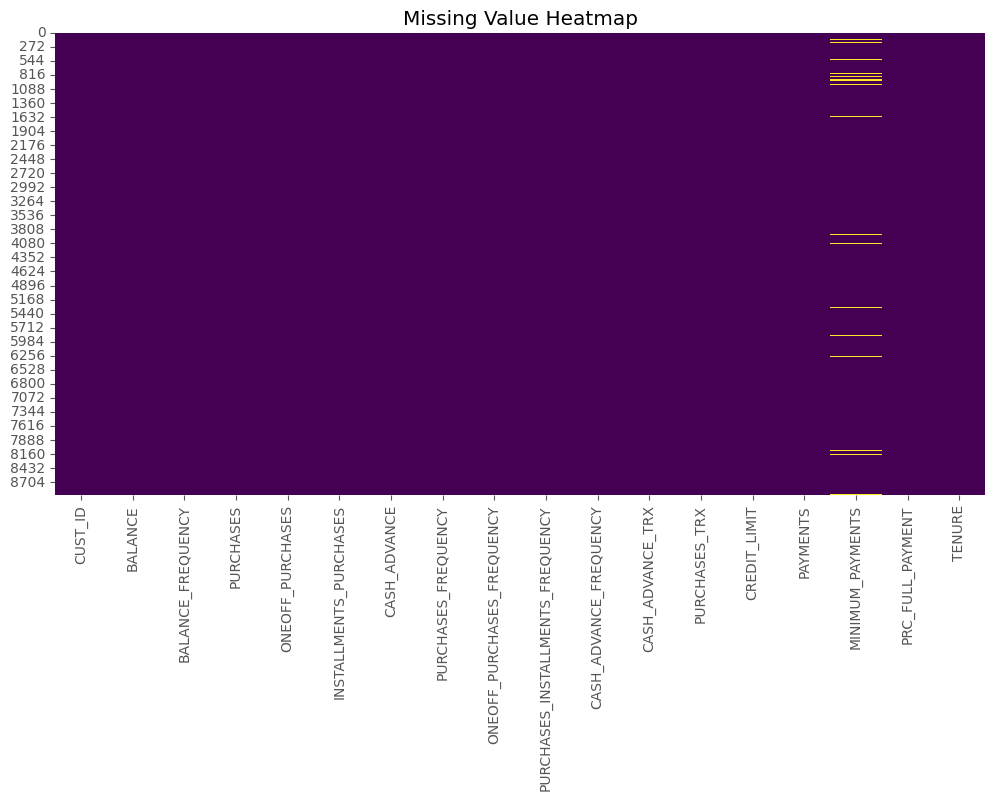

In [65]:
plt.figure(figsize=(12,6))

sns.heatmap(

    df.isnull(),

    cbar=False,
    
    cmap="viridis"
)

plt.title("Missing Value Heatmap")

plt.show()

In [66]:
duplicates = df.duplicated().sum()

print("Duplicate Rows :", duplicates)

Duplicate Rows : 0


In [67]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,1564.47,2081.53,0.00,128.28,873.39,2054.14,19043.14
BALANCE_FREQUENCY,8950.0,0.88,0.24,0.00,0.89,1.00,1.00,1.00
PURCHASES,8950.0,1003.20,2136.63,0.00,39.64,361.28,1110.13,49039.57
ONEOFF_PURCHASES,8950.0,592.44,1659.89,0.00,0.00,38.00,577.40,40761.25
INSTALLMENTS_PURCHASES,8950.0,411.07,904.34,0.00,0.00,89.00,468.64,22500.00
CASH_ADVANCE,8950.0,978.87,2097.16,0.00,0.00,0.00,1113.82,47137.21
PURCHASES_FREQUENCY,8950.0,0.49,0.40,0.00,0.08,0.50,0.92,1.00
ONEOFF_PURCHASES_FREQUENCY,8950.0,0.20,0.30,0.00,0.00,0.08,0.30,1.00
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,0.36,0.40,0.00,0.00,0.17,0.75,1.00
CASH_ADVANCE_FREQUENCY,8950.0,0.14,0.20,0.00,0.00,0.00,0.22,1.50


* Very different feature scales.
* Some features are highly skewed.
* Large variation in spending patterns.

This motivates the use of StandardScaler before DBSCAN.

Distribution of Numerical Features

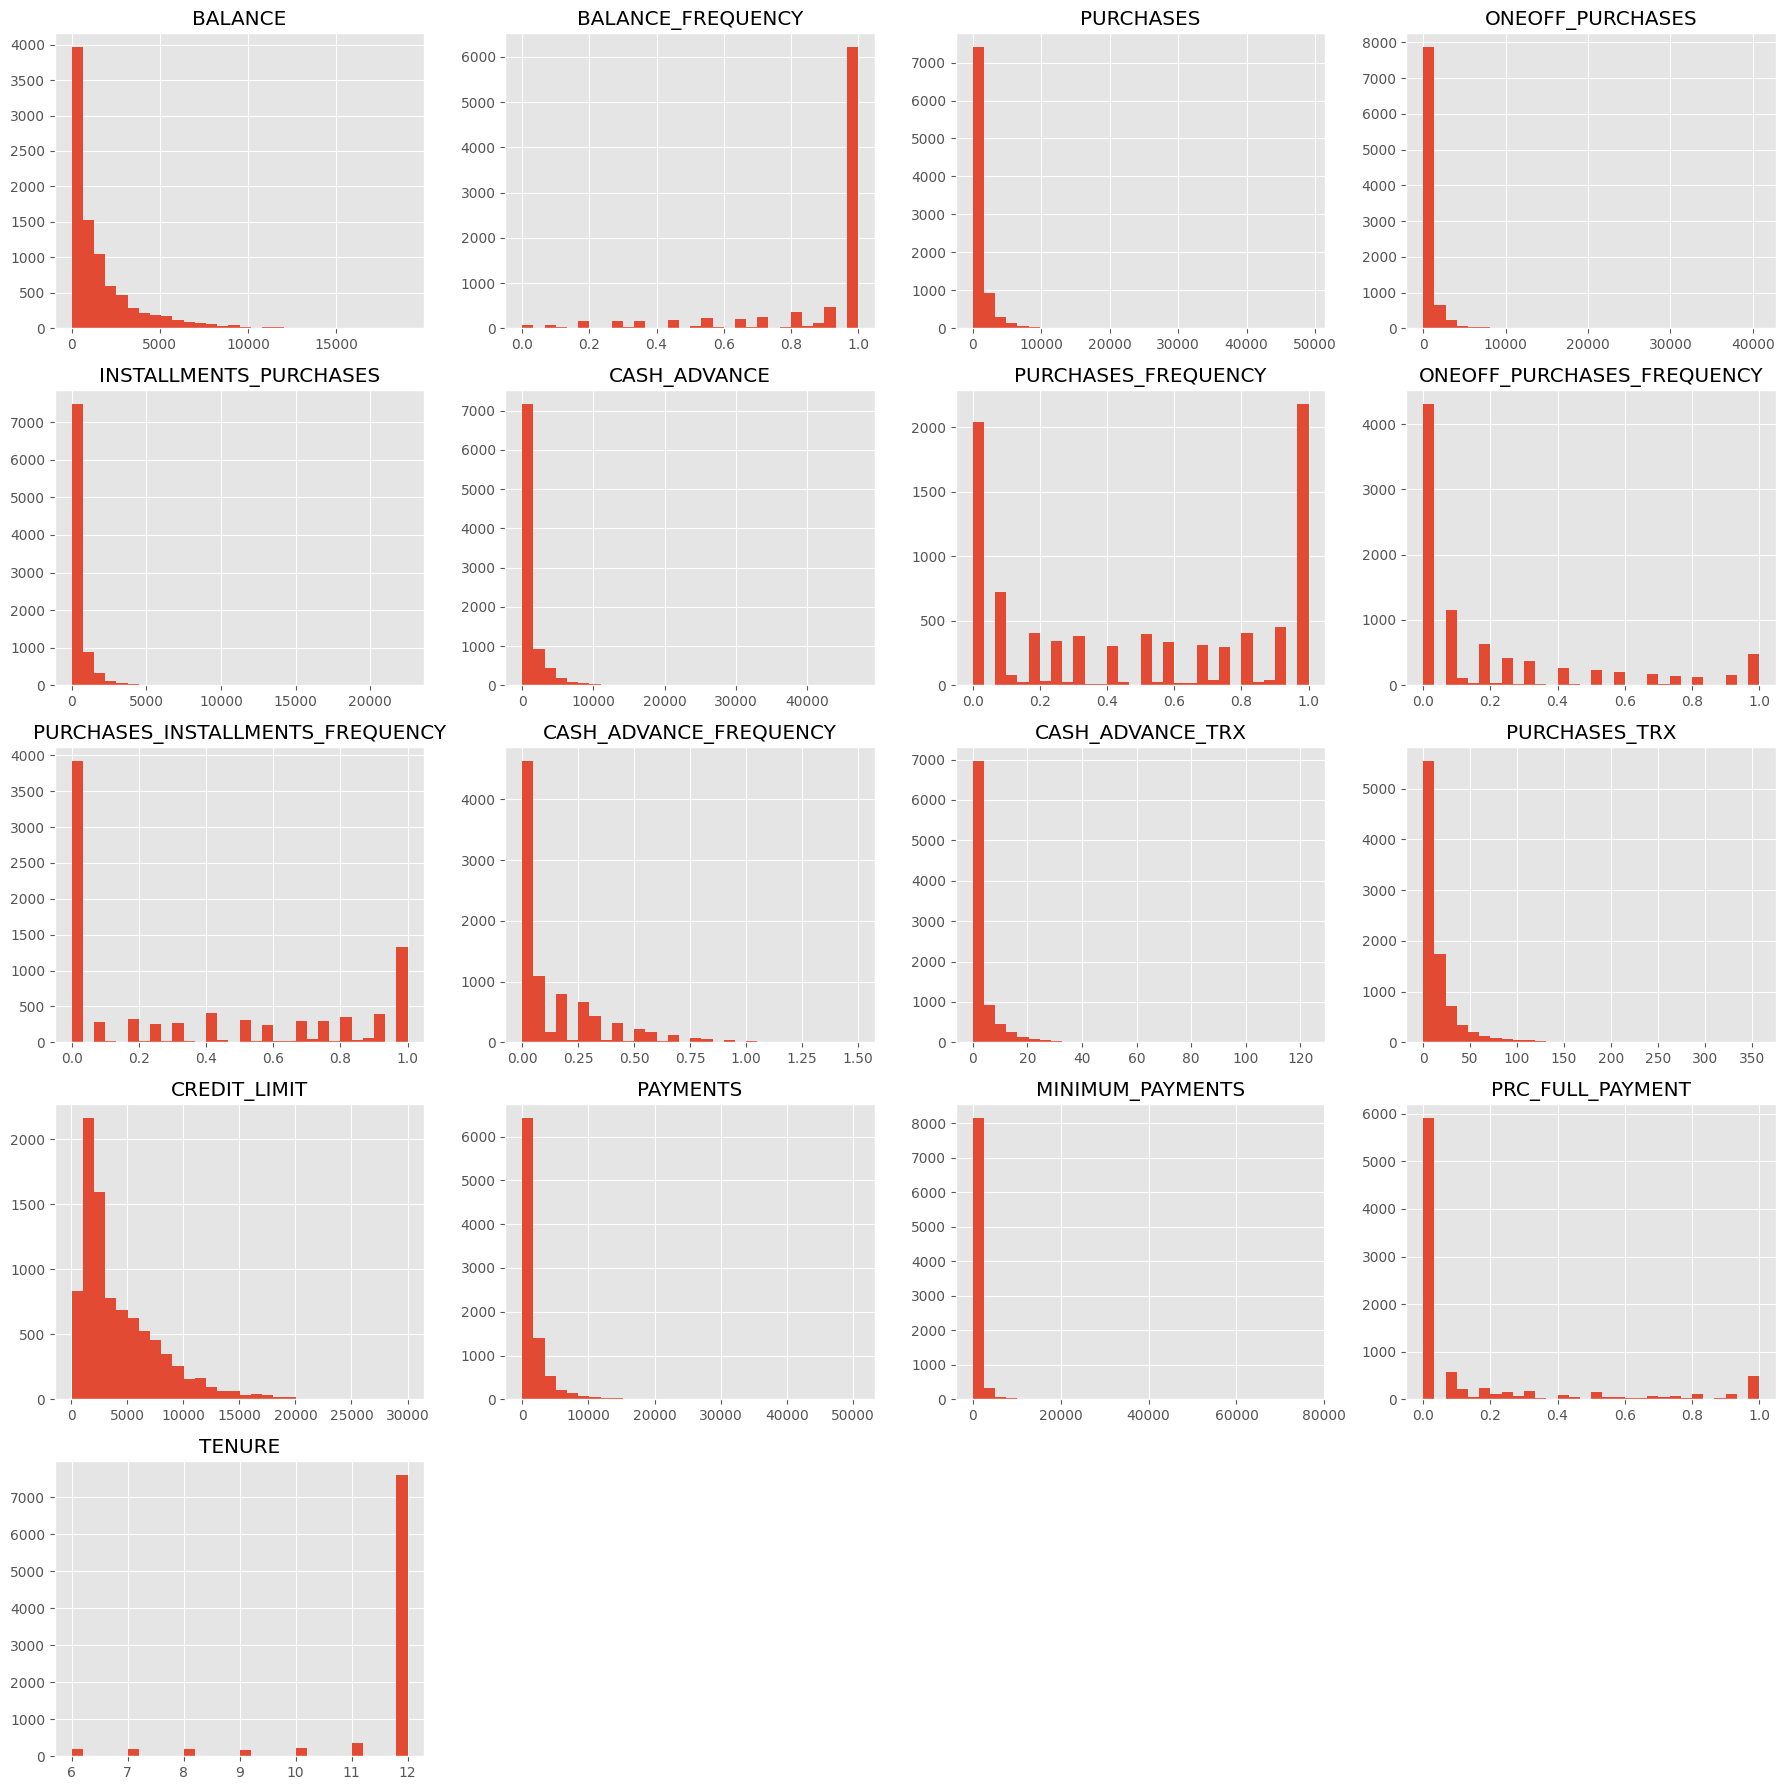

In [68]:

numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols].hist(

    figsize=(18,18),
    
    bins=30
)

plt.tight_layout()

plt.show()

Boxplots (Outlier Detection)

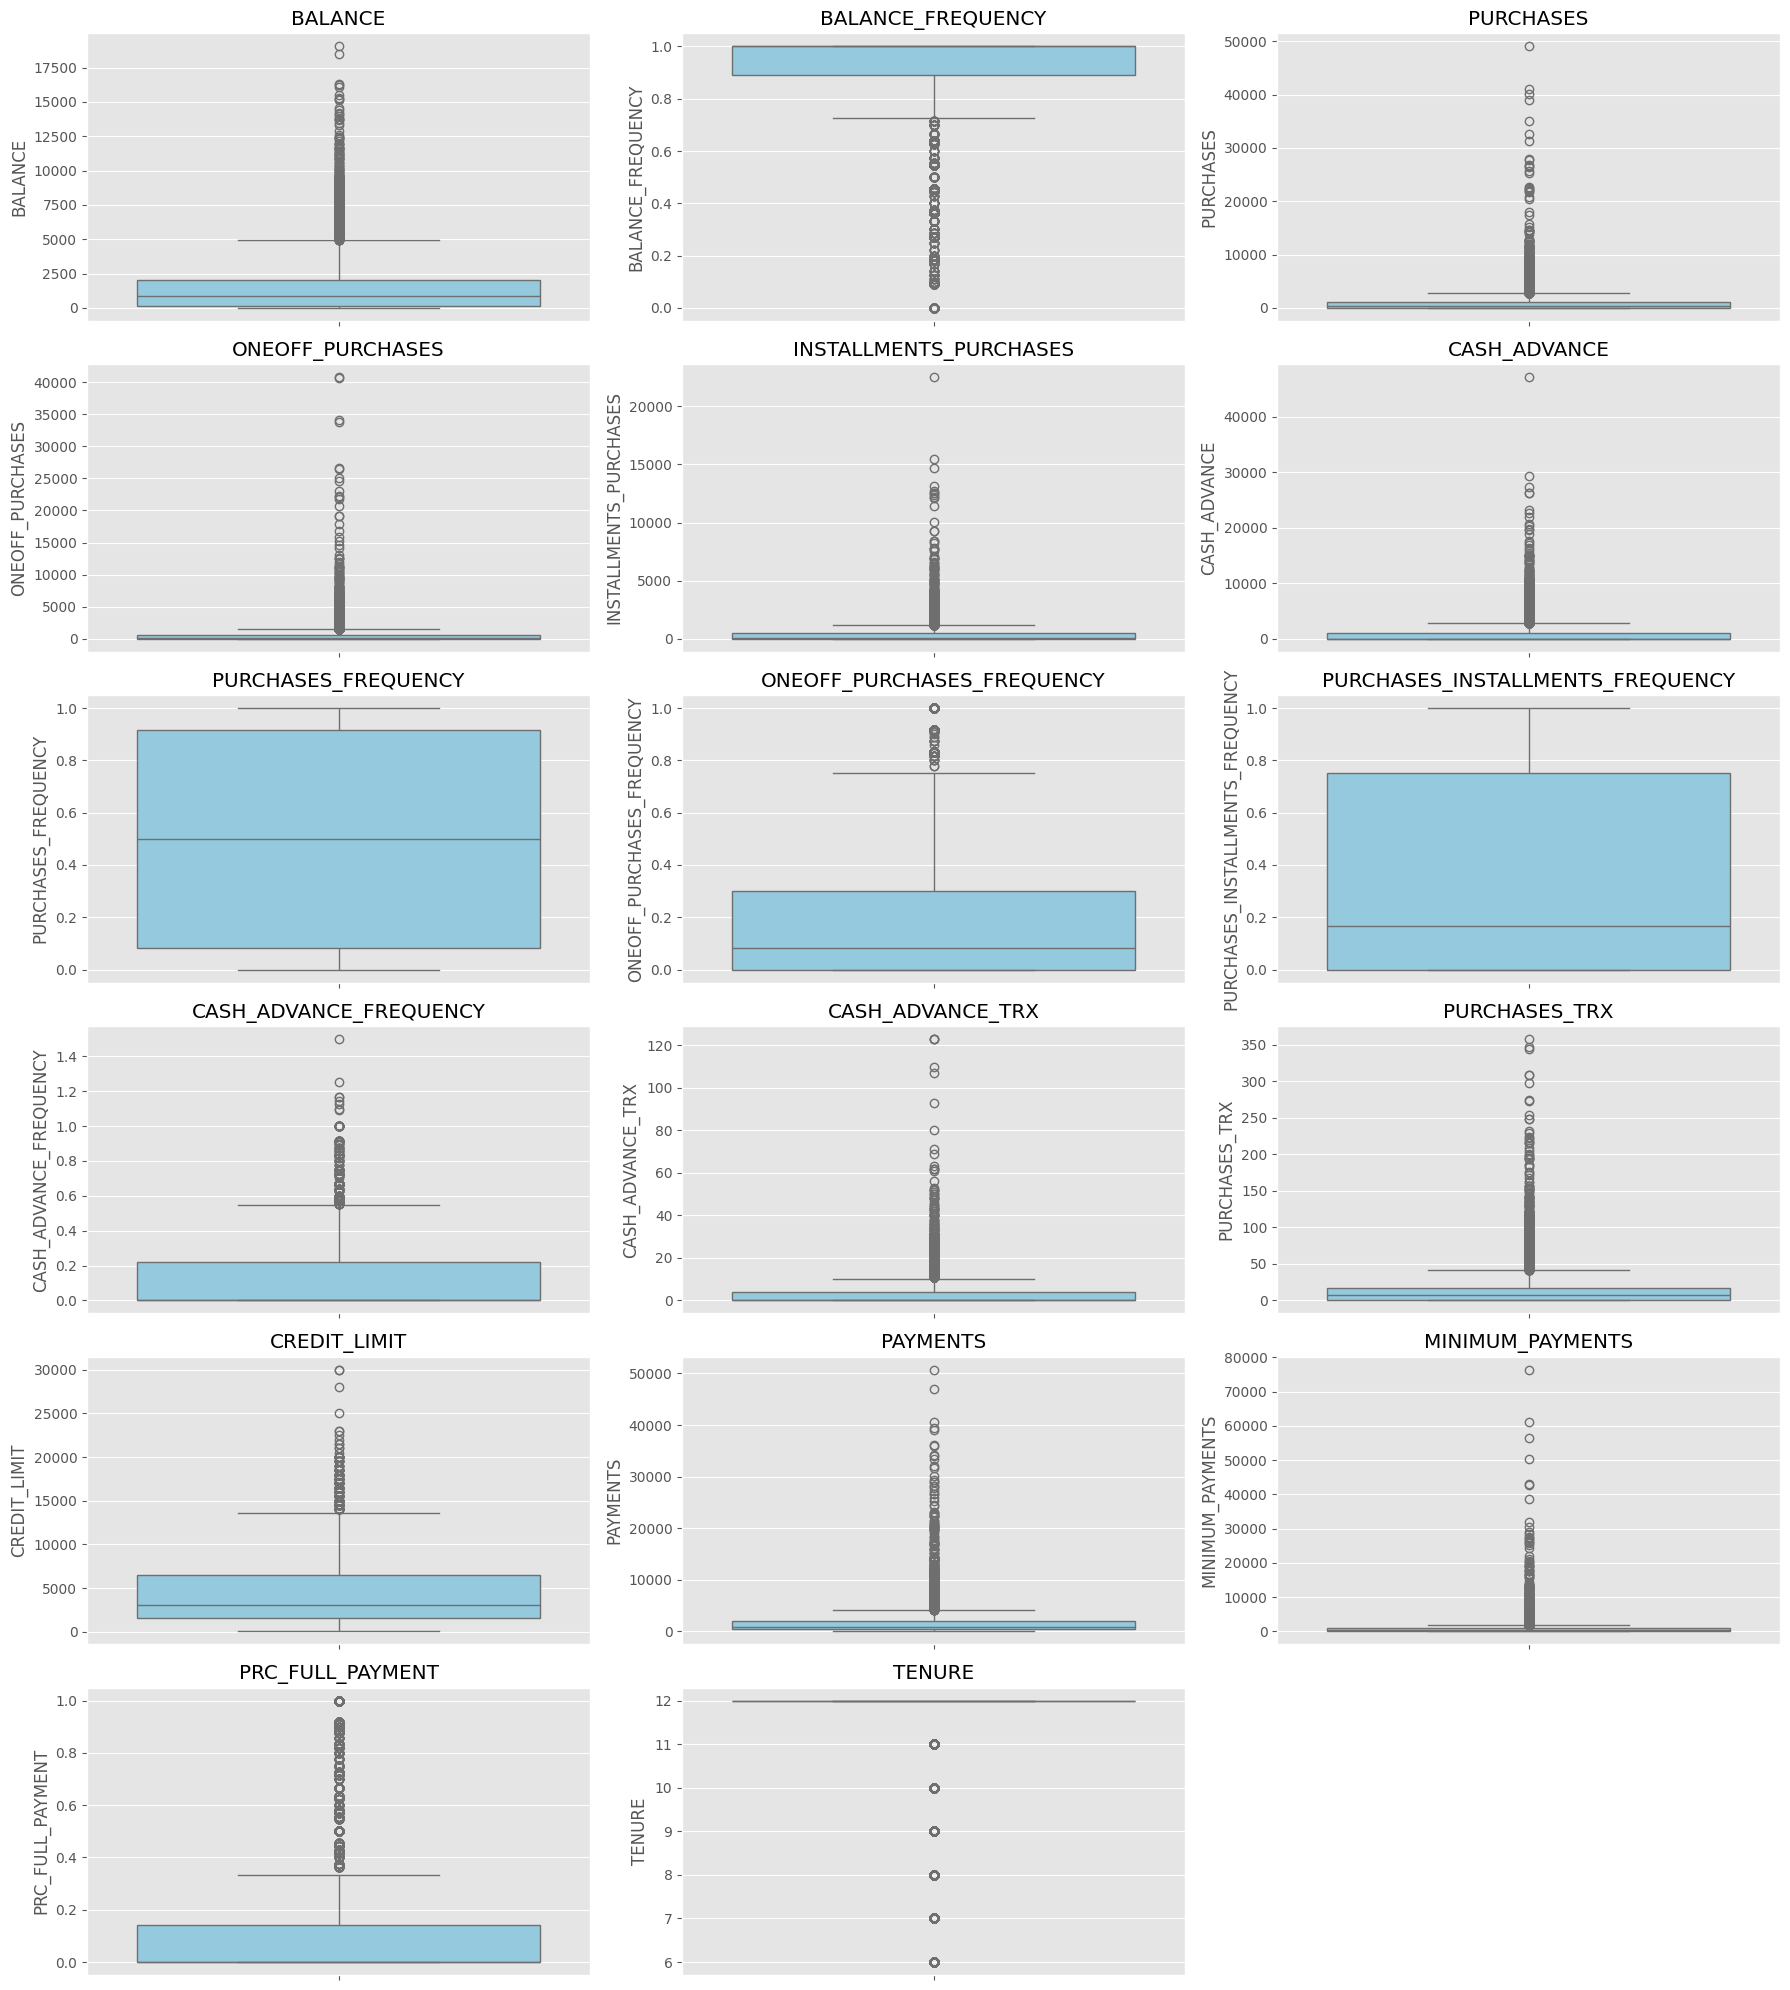

In [69]:

plt.figure(figsize=(18,20))

for i, column in enumerate(numeric_cols):

    plt.subplot(6,3,i+1)

    sns.boxplot(
        y=df[column],
        color="skyblue"
    )

    plt.title(column)

plt.tight_layout()

plt.show()



Observation

* Heavy outliers in **BALANCE**

* Outliers in **PURCHASES**

* Outliers in **PAYMENTS**

* Outliers in **CREDIT_LIMIT**

* Long-tailed distributions

Explain that DBSCAN naturally detects many of these as noise points, so we typically do not remove them before clustering.

Correlation Matrix

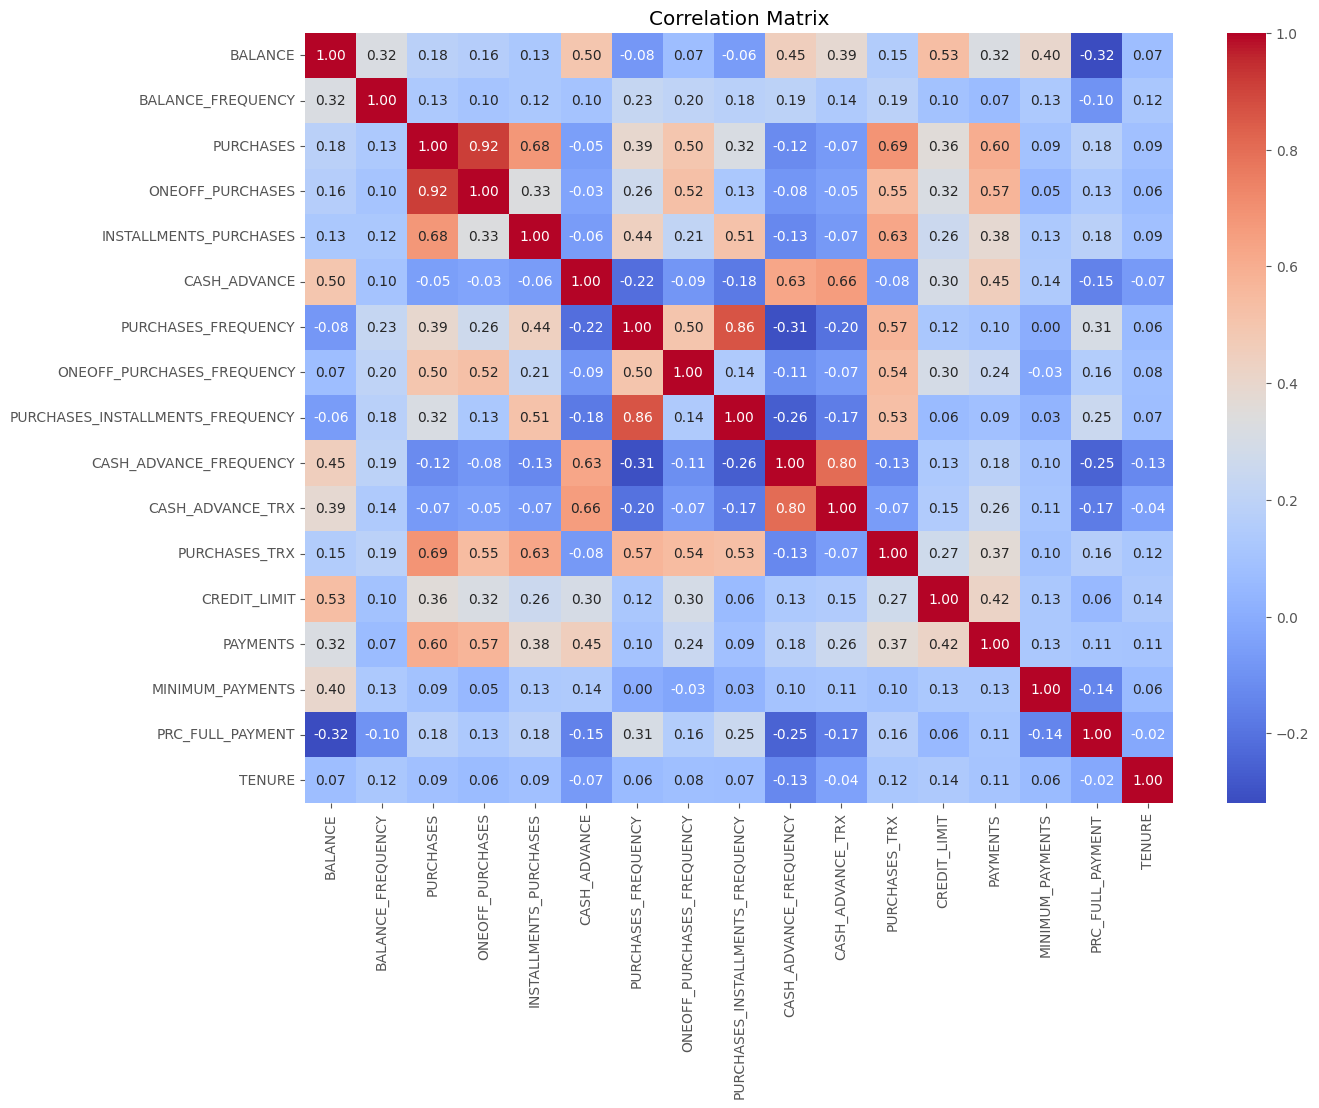

In [70]:

plt.figure(figsize=(14,10))

corr = df.drop(columns="CUST_ID").corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()



Strong correlations indicate variables carrying similar information.

Examples:

* PURCHASES ↔ PURCHASES_TRX
* PURCHASES ↔ PAYMENTS
* CASH_ADVANCE ↔ CASH_ADVANCE_TRX

Pairplot (Sample)

Since the dataset is large, use a random sample for visualization.

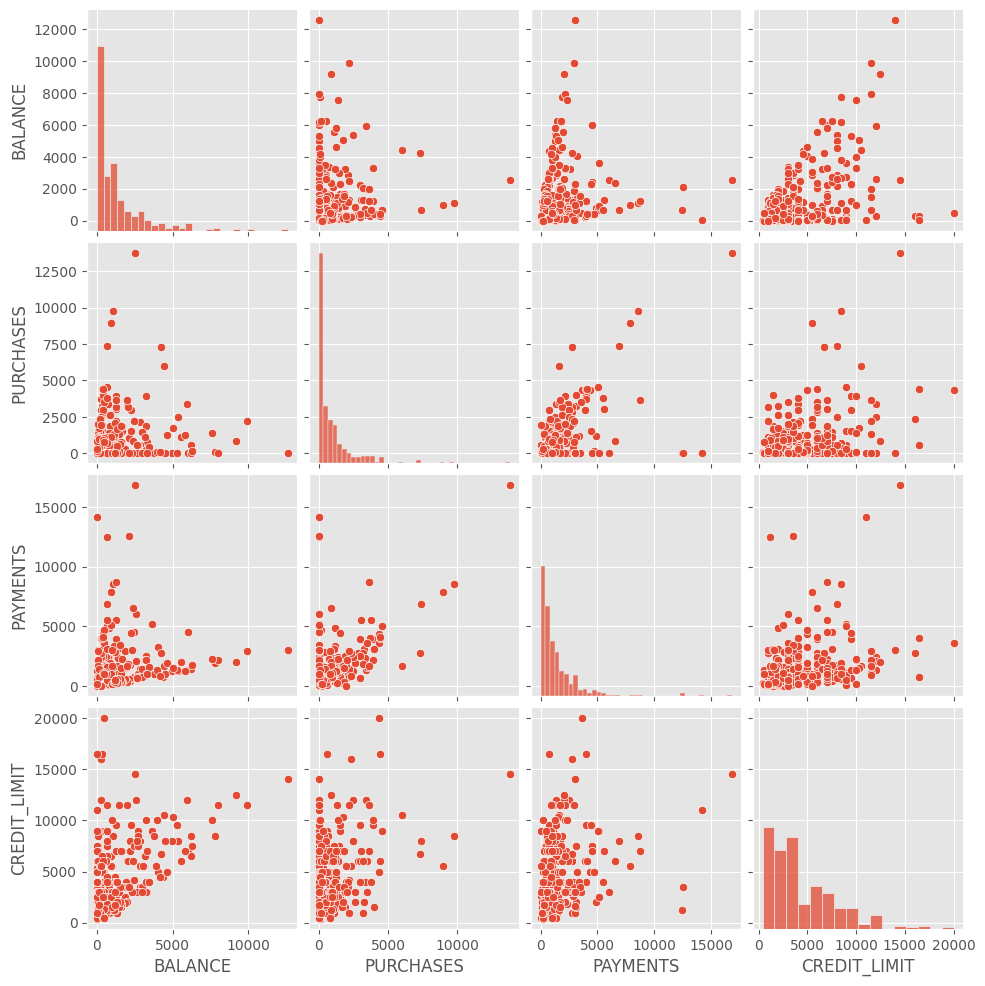

In [71]:

sample = df.sample(300, random_state=42)

sns.pairplot(

    sample[[
        "BALANCE",
        "PURCHASES",
        "PAYMENTS",
        "CREDIT_LIMIT"
    ]]

)

plt.show()

KDE Distribution

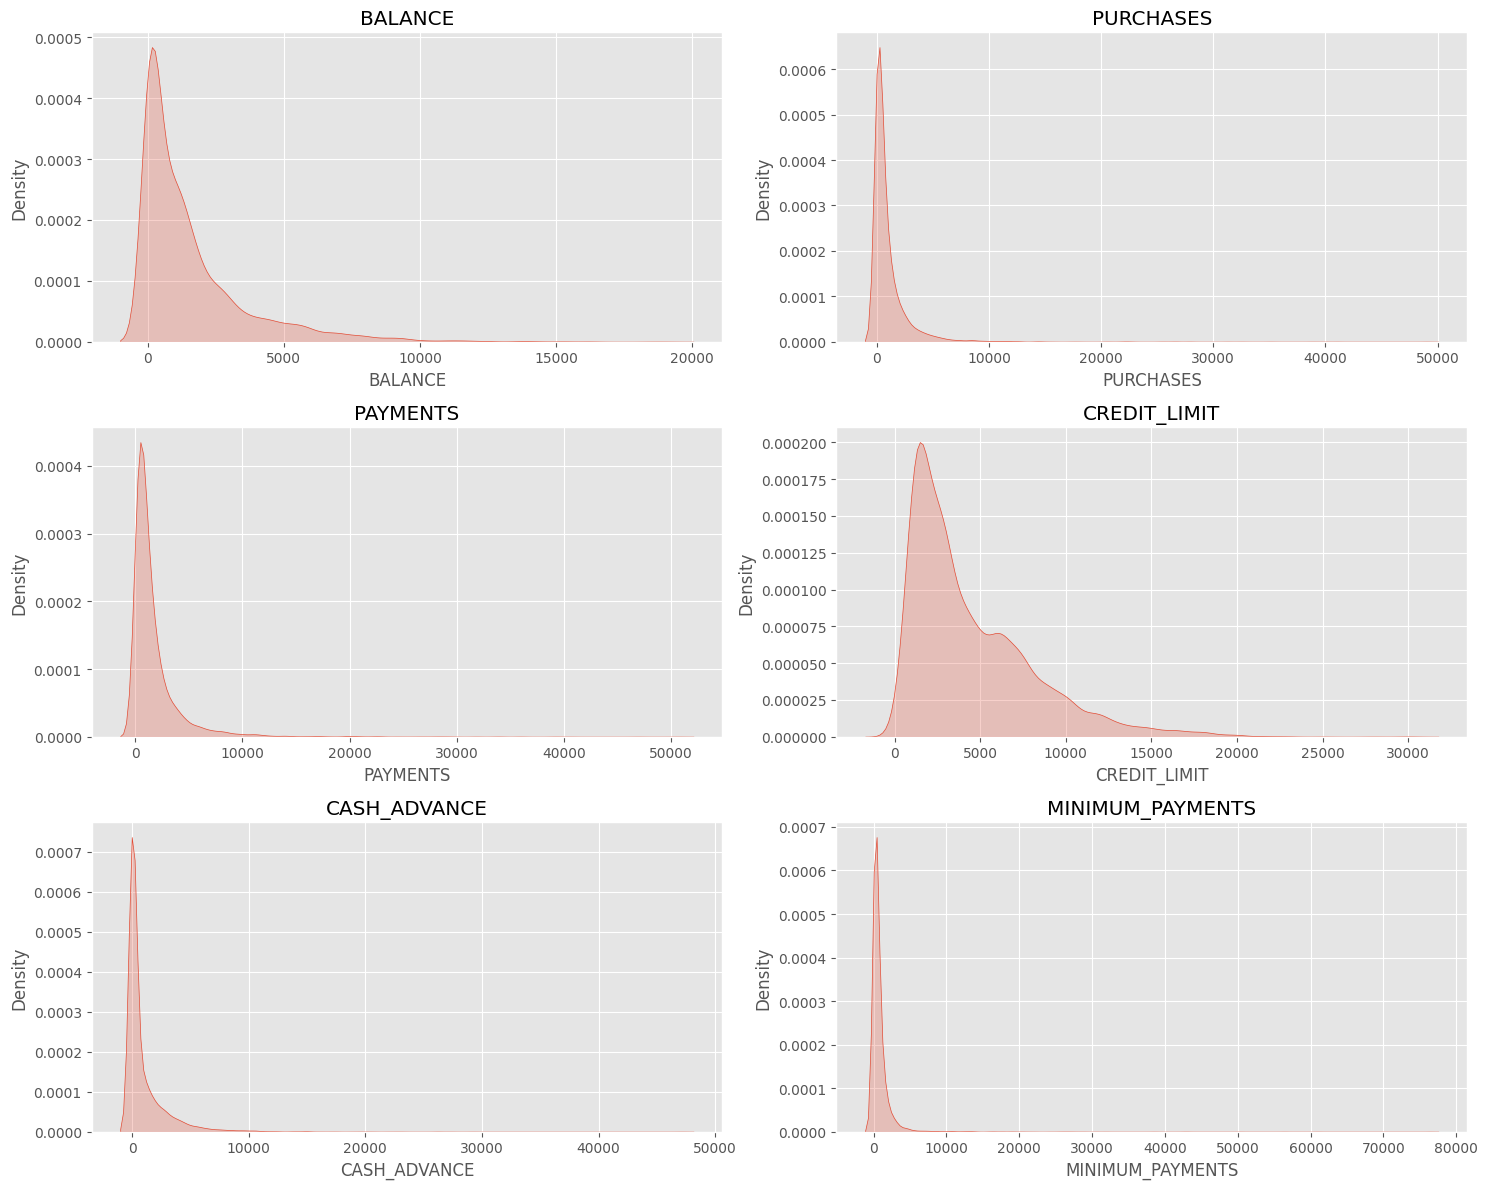

In [72]:

plt.figure(figsize=(15,12))

for i, column in enumerate([

    "BALANCE",
    "PURCHASES",
    "PAYMENTS",
    "CREDIT_LIMIT",
    "CASH_ADVANCE",
    "MINIMUM_PAYMENTS"
    
]):

    plt.subplot(3,2,i+1)

    sns.kdeplot(
        df[column],
        fill=True
    )

    plt.title(column)

plt.tight_layout()

plt.show()



Observation

Notice right-skewed distributions, reinforcing the importance of feature scaling.

Feature Skewness

In [73]:

skewness = df.drop(columns="CUST_ID").skew()

skewness.sort_values(ascending=False)

MINIMUM_PAYMENTS                    13.622797
ONEOFF_PURCHASES                    10.045083
PURCHASES                            8.144269
INSTALLMENTS_PURCHASES               7.299120
PAYMENTS                             5.907620
CASH_ADVANCE_TRX                     5.721298
CASH_ADVANCE                         5.166609
PURCHASES_TRX                        4.630655
BALANCE                              2.393386
PRC_FULL_PAYMENT                     1.942820
CASH_ADVANCE_FREQUENCY               1.828686
ONEOFF_PURCHASES_FREQUENCY           1.535613
CREDIT_LIMIT                         1.522464
PURCHASES_INSTALLMENTS_FREQUENCY     0.509201
PURCHASES_FREQUENCY                  0.060164
BALANCE_FREQUENCY                   -2.023266
TENURE                              -2.943017
dtype: float64


* Skewness > 1 indicates highly skewed features.

* Highly skewed variables may benefit from log transformation, though for this notebook we will proceed with scaling to keep the workflow focused on DBSCAN.


Conclude:

* Dataset contains **8,950 customers**.

* Only a few missing values.

* No duplicate records.

* Features have very different ranges.

* Many variables contain extreme values.

* Several features are highly correlated.

* Most numerical variables are right-skewed.

* Feature scaling is essential before applying DBSCAN.


Data Preprocessing


DBSCAN is a **distance-based clustering algorithm**, so preprocessing is one of the most critical steps. Features with larger numerical ranges can dominate the distance calculations, leading to poor clustering results.

In [74]:
data = df.copy()

print("Working dataset created successfully.")

Working dataset created successfully.


Remove Customer ID

`CUST_ID` is only an identifier and does not contain meaningful information for clustering.

In [75]:
data.drop("CUST_ID", axis=1, inplace=True)

print("Remaining Features:", data.shape[1])

Remaining Features: 17


Handle Missing Values


In [76]:
data.isnull().sum()

BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

Since these are numerical variables, we will replace missing values using the **median**, which is more robust to outliers than the mean.


In [77]:
# Fill missing values with median

data["MINIMUM_PAYMENTS"] = data["MINIMUM_PAYMENTS"].fillna(

    data["MINIMUM_PAYMENTS"].median()
)

data["CREDIT_LIMIT"] = data["CREDIT_LIMIT"].fillna(
    
    data["CREDIT_LIMIT"].median()
)

In [78]:
data.isnull().sum()

BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

Feature Scaling

DBSCAN calculates distances between observations. Since the variables have very different ranges (for example, `BALANCE` vs. `PURCHASES_FREQUENCY`), scaling is essential.

We will use **StandardScaler**, which transforms each feature to have:

* Mean = 0
* Standard Deviation = 1


In [79]:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(data)


In [80]:
scaled_df = pd.DataFrame(

    scaled_data,
    
    columns=data.columns
)

scaled_df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-0.731989,-0.249434,-0.424900,-0.356934,-0.349079,-0.466786,-0.806490,-0.678661,-0.707313,-0.675349,-0.476070,-0.511333,-0.960378,-0.528979,-0.302400,-0.525551,0.36068
1,0.786961,0.134325,-0.469552,-0.356934,-0.454576,2.605605,-1.221758,-0.678661,-0.916995,0.573963,0.110074,-0.591796,0.688678,0.818642,0.097500,0.234227,0.36068
2,0.447135,0.518084,-0.107668,0.108889,-0.454576,-0.466786,1.269843,2.673451,-0.916995,-0.675349,-0.476070,-0.109020,0.826100,-0.383805,-0.093293,-0.525551,0.36068
3,0.049099,-1.016953,0.232058,0.546189,-0.454576,-0.368653,-1.014125,-0.399319,-0.916995,-0.258913,-0.329534,-0.551565,0.826100,-0.598688,-0.228307,-0.525551,0.36068
4,-0.358775,0.518084,-0.462063,-0.347294,-0.454576,-0.466786,-1.014125,-0.399319,-0.916995,-0.675349,-0.476070,-0.551565,-0.905410,-0.364368,-0.257266,-0.525551,0.36068


Verify Scaling

In [81]:
#Before Scaling

data.describe().T[["mean", "std"]]

,mean,std
BALANCE,1564.474828,2081.531879
BALANCE_FREQUENCY,0.877271,0.236904
PURCHASES,1003.204834,2136.634782
ONEOFF_PURCHASES,592.437371,1659.887917
INSTALLMENTS_PURCHASES,411.067645,904.338115
CASH_ADVANCE,978.871112,2097.163877
PURCHASES_FREQUENCY,0.490351,0.401371
ONEOFF_PURCHASES_FREQUENCY,0.202458,0.298336
PURCHASES_INSTALLMENTS_FREQUENCY,0.364437,0.397448
CASH_ADVANCE_FREQUENCY,0.135144,0.200121


In [82]:
# After Scaling

scaled_df.describe().T[["mean", "std"]]

,mean,std
BALANCE,-2.540488e-17,1.000056
BALANCE_FREQUENCY,1.587805e-16,1.000056
PURCHASES,3.175610e-18,1.000056
ONEOFF_PURCHASES,-6.033659e-17,1.000056
INSTALLMENTS_PURCHASES,3.175610e-17,1.000056
CASH_ADVANCE,-6.351220e-18,1.000056
PURCHASES_FREQUENCY,9.328354e-17,1.000056
ONEOFF_PURCHASES_FREQUENCY,1.905366e-17,1.000056
PURCHASES_INSTALLMENTS_FREQUENCY,5.716098e-17,1.000056
CASH_ADVANCE_FREQUENCY,-1.595744e-16,1.000056


This confirms that all features are now on the same scale.

Visual Comparison: Before vs. After Scaling

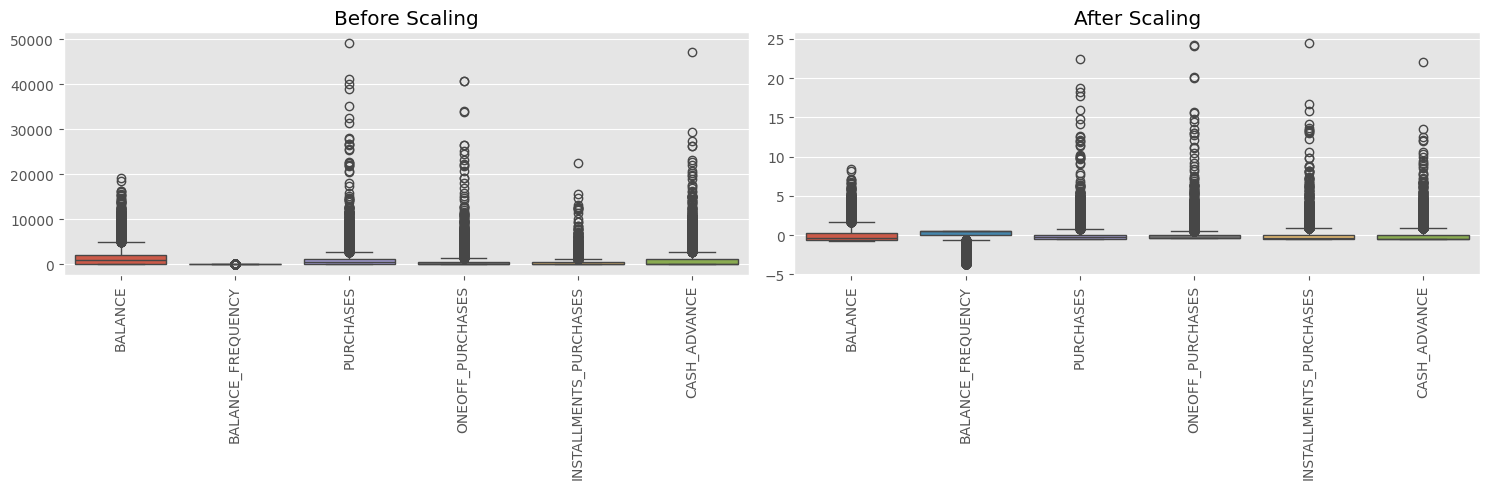

In [83]:

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(data=data.iloc[:, :6], ax=axes[0])
axes[0].set_title("Before Scaling")
axes[0].tick_params(axis="x", rotation=90)

sns.boxplot(data=scaled_df.iloc[:, :6], ax=axes[1])
axes[1].set_title("After Scaling")
axes[1].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()


Observation

* Before scaling, variables have very different ranges.
* After scaling, all variables are standardized, making Euclidean distance calculations meaningful for DBSCAN.

Distribution After Scaling


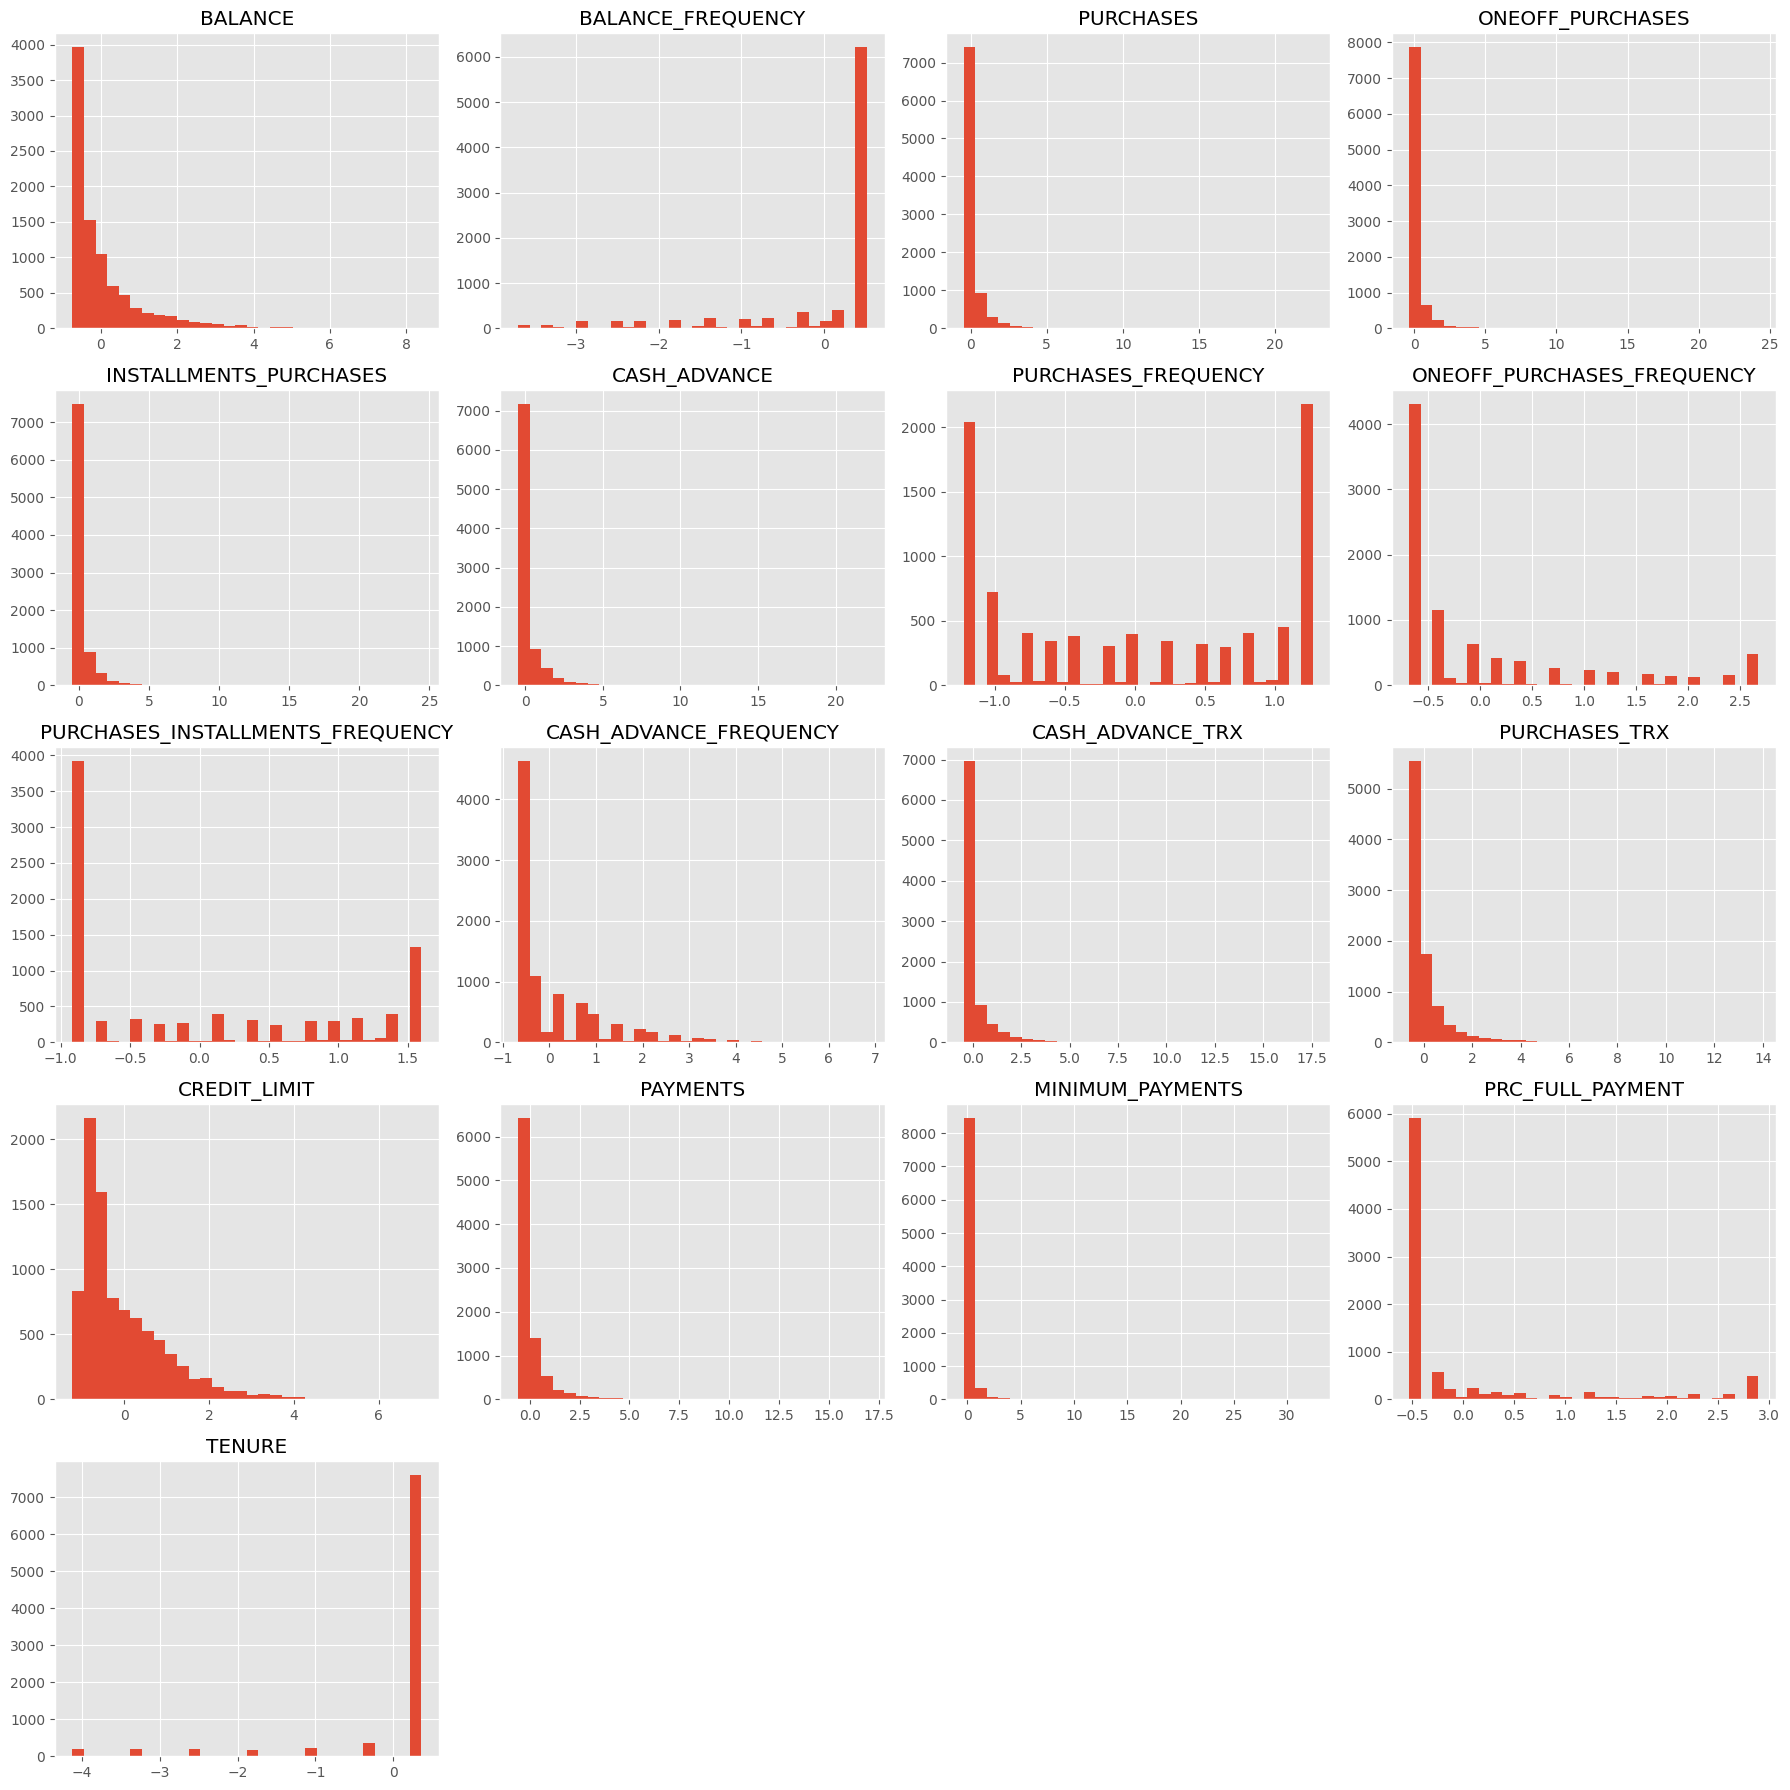

In [84]:
scaled_df.hist(
    figsize=(18, 18),
    bins=30
)

plt.tight_layout()

plt.show()


observe that the distributions remain similar in shape, but are now centered around zero.

Final Feature Matrix

In [85]:
X = scaled_df.copy()

print("Final Feature Matrix Shape:", X.shape)

Final Feature Matrix Shape: (8950, 17)


* Removed the identifier (`CUST_ID`).

* Imputed missing values using the median.

* Standardized all numerical features.

* Created the final feature matrix `X` for clustering.

Choosing the Optimal `eps` for DBSCAN

Unlike K-Means, DBSCAN does **not require specifying the number of clusters**. Instead, it relies on two important hyperparameters:

`eps` (Epsilon):** The maximum distance between two points for them to be considered neighbors.

`min_samples`:** The minimum number of neighboring points required for a point to become a **core point**.

Choosing appropriate values for these parameters is crucial for obtaining meaningful clusters.

Understanding `eps`

`eps` defines the radius around each data point.

* **Too small:** Most points become noise (`-1`), resulting in many tiny clusters or no clusters.
* **Too large:** Different clusters merge together into one large cluster.



### Illustration

```text
Small eps

      ●

          ●


   ●

(Most points remain isolated)

--------------------------------------------

Optimal eps

      ● ● ●

    ● ● ● ●

       ● ●

(Dense region becomes one cluster)

--------------------------------------------

Large eps

● ● ● ● ● ● ● ● ● ●

(All points merge into one cluster)
```

Understanding `min_samples`

`min_samples` determines how many neighboring points are needed to form a dense region.


Common rule of thumb:


min_samples = 2 × Number of Features

Our dataset contains **17 features**.

Therefore,


min_samples = 34


For educational purposes, we will also experiment with smaller values (e.g., 5 and 10) to illustrate their effect on clustering.


Finding the Optimal `eps` Using the K-Distance Graph

The K-Distance Graph is the most common method for selecting `eps`.

### Steps:

1. Compute the distance from each point to its *k*-th nearest neighbor (where *k* = `min_samples`).

2. Sort these distances in ascending order.

3. Plot the sorted distances.

4. Identify the **elbow (knee)** in the curve.

5. The distance at this elbow is a good estimate for `eps`.


Compute Nearest Neighbors

In [86]:

from sklearn.neighbors import NearestNeighbors

k = 34

neighbors = NearestNeighbors(n_neighbors=k)

neighbors_fit = neighbors.fit(X)

distances, indices = neighbors_fit.kneighbors(X)


Sort the Distances

We use the distance to the **34th nearest neighbor** for each point.

In [87]:
distance_values = np.sort(distances[:, k-1])

Plot the K-Distance Graph

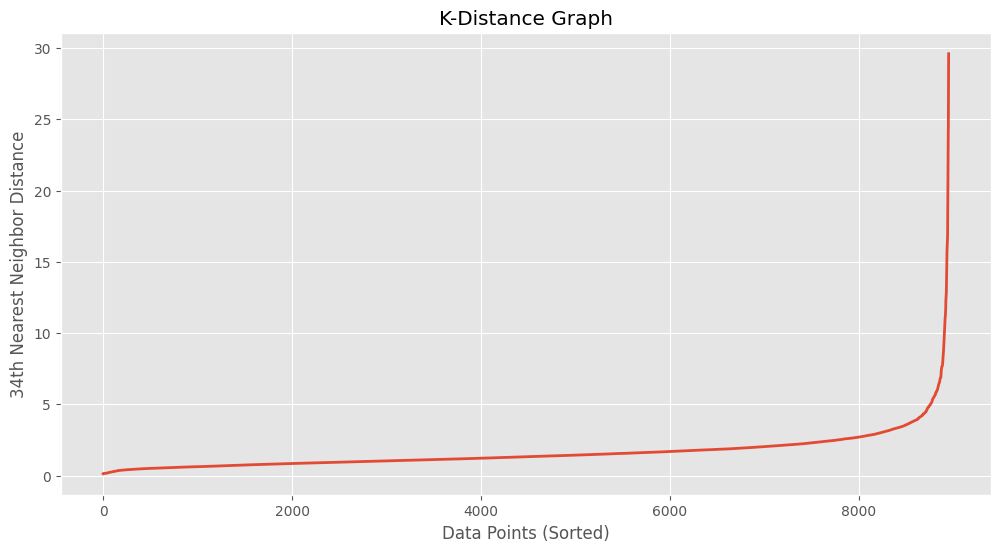

In [88]:

plt.figure(figsize=(12,6))

plt.plot(distance_values, linewidth=2)

plt.title("K-Distance Graph")

plt.xlabel("Data Points (Sorted)")

plt.ylabel("34th Nearest Neighbor Distance")

plt.grid(True)

plt.show()

Selecting `eps`

Suppose the elbow occurs around **2.3**.

We choose:

```python
eps = 2.3
```

> **Note:** The exact value depends on the dataset and should be determined by visually inspecting the graph.


In [89]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=2.3,
    min_samples=34
)

cluster_labels = dbscan.fit_predict(X)


Attach Cluster Labels to the Dataset

In [90]:

result = data.copy()

result["Cluster"] = cluster_labels

result.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Cluster
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,0
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,0
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,0
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,312.343947,0.000000,12,0
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,0


Count the Number of Clusters

In [91]:

n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)

print("Number of Clusters:", n_clusters)

Number of Clusters: 1


Count the Number of Noise Points

In [92]:

noise_points = np.sum(cluster_labels == -1)

print("Number of Noise Points:", noise_points)

Number of Noise Points: 689


Cluster Distribution

In [93]:
cluster_counts = pd.Series(cluster_labels).value_counts().sort_index()

print(cluster_counts)

-1     689
 0    8261
Name: count, dtype: int64


Visualize Cluster Sizes

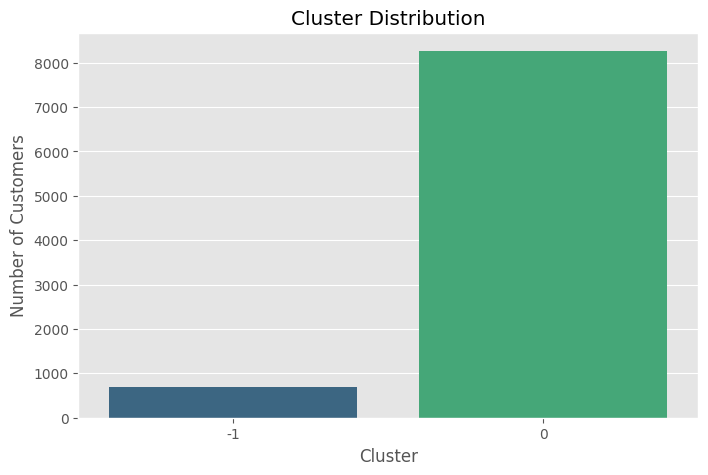

In [94]:

plt.figure(figsize=(8,5))

sns.countplot(
    x=cluster_labels,
    palette="viridis"
)

plt.title("Cluster Distribution")

plt.xlabel("Cluster")

plt.ylabel("Number of Customers")

plt.show()




### Interpretation

analyze:

* Whether clusters are balanced or imbalanced.

* The proportion of noise points.

* Whether the chosen `eps` seems appropriate.


Cluster Evaluation and Visualization

Unlike supervised learning, clustering does not have target labels. Therefore, we evaluate the quality of clusters using internal metrics such as the **Silhouette Score** and by visually inspecting the clusters.

Overview of Evaluation Metrics


For DBSCAN, common evaluation methods include:

* Number of Clusters
* Number of Noise Points
* Silhouette Score
* Davies-Bouldin Index
* Calinski-Harabasz Index
* Cluster Size Distribution
* Visual Inspection using PCA

> **Important:** Unlike K-Means, DBSCAN does **not** use Inertia or the Elbow Method for evaluation.

Silhouette Score

The Silhouette Score measures how well each point fits within its assigned cluster.

### Formula

[
\text{Silhouette Score} = \frac{b-a}{\max(a,b)}
]

where:

* **a** = Average distance to points within the same cluster
* **b** = Average distance to the nearest neighboring cluster

### Interpretation

| Score       | Interpretation       |
| ----------- | -------------------- |
| Close to 1  | Excellent clustering |
| Around 0    | Overlapping clusters |
| Less than 0 | Poor clustering      |

Important Note

Noise points (`-1`) should be excluded before calculating the Silhouette Score.

<!-- cluster_labels = [0,-1]

mask = cluster_labels != -1 [0]

X_valid = X[mask] -->

In [95]:
mask = cluster_labels != -1

X_valid = X[mask]

labels_valid = cluster_labels[mask]


Calculate Silhouette Score


In [96]:

# from sklearn.metrics import silhouette_score

# score = silhouette_score(
#     X_valid,
#     labels_valid
# )

# print("Silhouette Score :", round(score,3))


Davies-Bouldin Index


A lower Davies-Bouldin Index indicates better clustering.

In [97]:
# from sklearn.metrics import davies_bouldin_score

# db_index = davies_bouldin_score(
#     X_valid,
#     labels_valid
# )

# print("Davies-Bouldin Index :", round(db_index,3))

Calinski-Harabasz Score



Higher values indicate better-defined clusters.

In [98]:

# from sklearn.metrics import calinski_harabasz_score

# ch_score = calinski_harabasz_score(
#     X_valid,
#     labels_valid
# )

# print("Calinski-Harabasz Score :", round(ch_score,2))


Summary of Evaluation Metrics


In [99]:

# evaluation = pd.DataFrame({

#     "Metric":[
#         "Clusters",
#         "Noise Points",
#         "Silhouette Score",
#         "Davies-Bouldin",
#         "Calinski-Harabasz"
#     ],

#     "Value":[
#         n_clusters,
#         noise_points,
#         round(score,3),
#         round(db_index,3),
#         round(ch_score,2)
#     ]

# })

# evaluation

PCA for Cluster Visualization

Since the dataset has 17 dimensions, we reduce it to two principal components for visualization.



In [100]:

from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)



Explained Variance


In [101]:

print(
    pca.explained_variance_ratio_
)

[0.27297671 0.2031378 ]



This means the first two principal components explain approximately **48%** of the total variance.


Create PCA DataFrame

In [102]:

pca_df = pd.DataFrame({

    "PC1": X_pca[:,0],

    "PC2": X_pca[:,1],

    "Cluster": cluster_labels

})

pca_df.head()

,PC1,PC2,Cluster
0,-1.683649,-1.072241,0
1,-1.134085,2.509150,0
2,0.969395,-0.383577,0
3,-0.888220,0.004648,0
4,-1.600021,-0.683795,0


Scatter Plot of Clusters

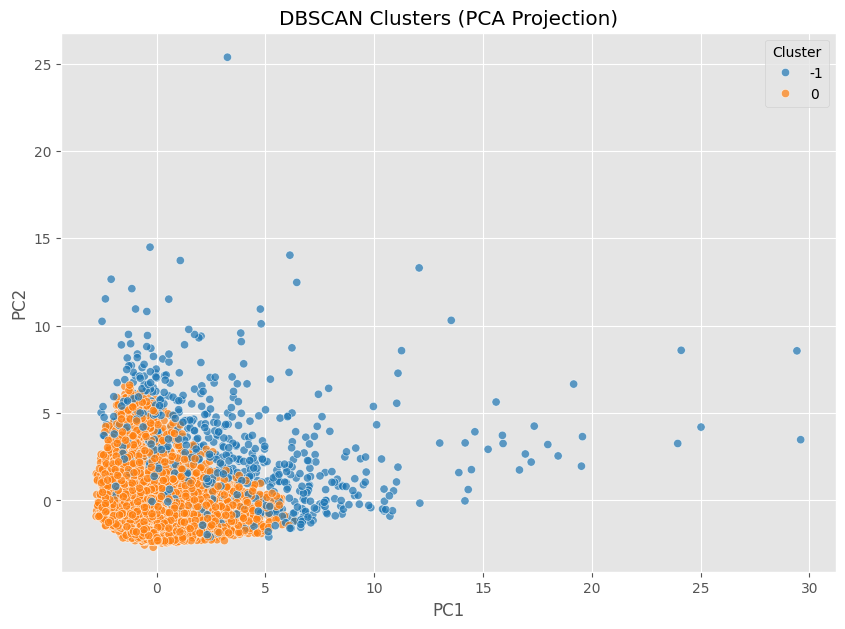

In [103]:

plt.figure(figsize=(10,7))

sns.scatterplot(

    data=pca_df,

    x="PC1",

    y="PC2",

    hue="Cluster",

    palette="tab10",

    alpha=0.7

)

plt.title("DBSCAN Clusters (PCA Projection)")

plt.show()

Interpretation

observe:

* Distinct customer clusters.
* Dense regions identified by DBSCAN.
* Separation between clusters.
* Outliers positioned away from dense groups.


Highlight Noise Points

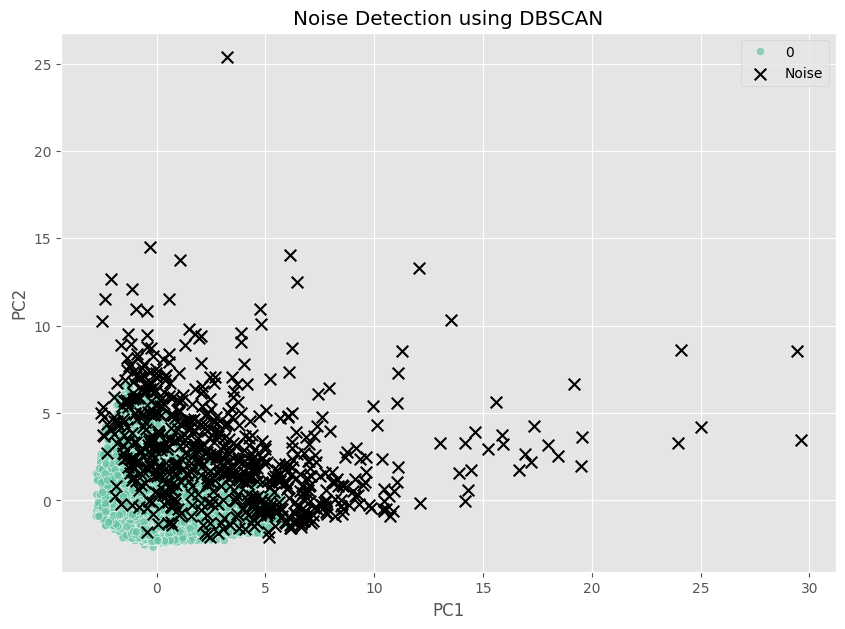

In [104]:

plt.figure(figsize=(10,7))

sns.scatterplot(

    data=pca_df[pca_df["Cluster"] != -1],

    x="PC1",

    y="PC2",

    hue="Cluster",

    palette="Set2",

    alpha=0.7

)

plt.scatter(

    pca_df[pca_df["Cluster"] == -1]["PC1"],

    pca_df[pca_df["Cluster"] == -1]["PC2"],

    color="black",

    marker="x",

    s=70,

    label="Noise"

)

plt.legend()

plt.title("Noise Detection using DBSCAN")

plt.show()



* Colored points represent clusters.
* Black **×** markers represent noise (outliers).


Cluster Size Visualization

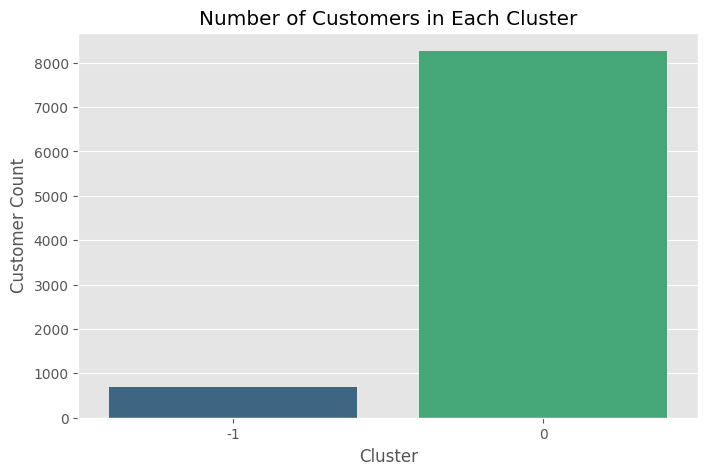

In [105]:

cluster_size = result["Cluster"].value_counts().sort_index()

plt.figure(figsize=(8,5))

sns.barplot(

    x=cluster_size.index.astype(str),

    y=cluster_size.values,

    palette="viridis"

)

plt.title("Number of Customers in Each Cluster")

plt.xlabel("Cluster")

plt.ylabel("Customer Count")

plt.show()


Percentage of Noise Points

In [106]:
noise_percentage = (

    (noise_points/len(result))*100

)

print(

    f"Noise Percentage : {noise_percentage:.2f}%"

)

Noise Percentage : 7.70%


Cluster Centroids (Exploratory)


Although DBSCAN does not compute centroids, we can calculate the mean feature values for each cluster to understand their characteristics.

In [107]:

cluster_profile = result.groupby("Cluster").mean()

cluster_profile

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
-1,4337.455759,0.932524,4380.896633,2851.669739,1530.129652,3583.843829,0.693863,0.439584,0.536272,0.297864,10.869376,50.481858,9380.507983,7136.760406,3565.814867,0.202936,11.319303
0,1333.197275,0.872662,721.492008,404.008476,317.733457,761.606108,0.473377,0.182680,0.350106,0.121573,2.613243,11.726304,4086.751983,1282.460907,617.972294,0.149609,11.533834


Heatmap of Cluster Profiles

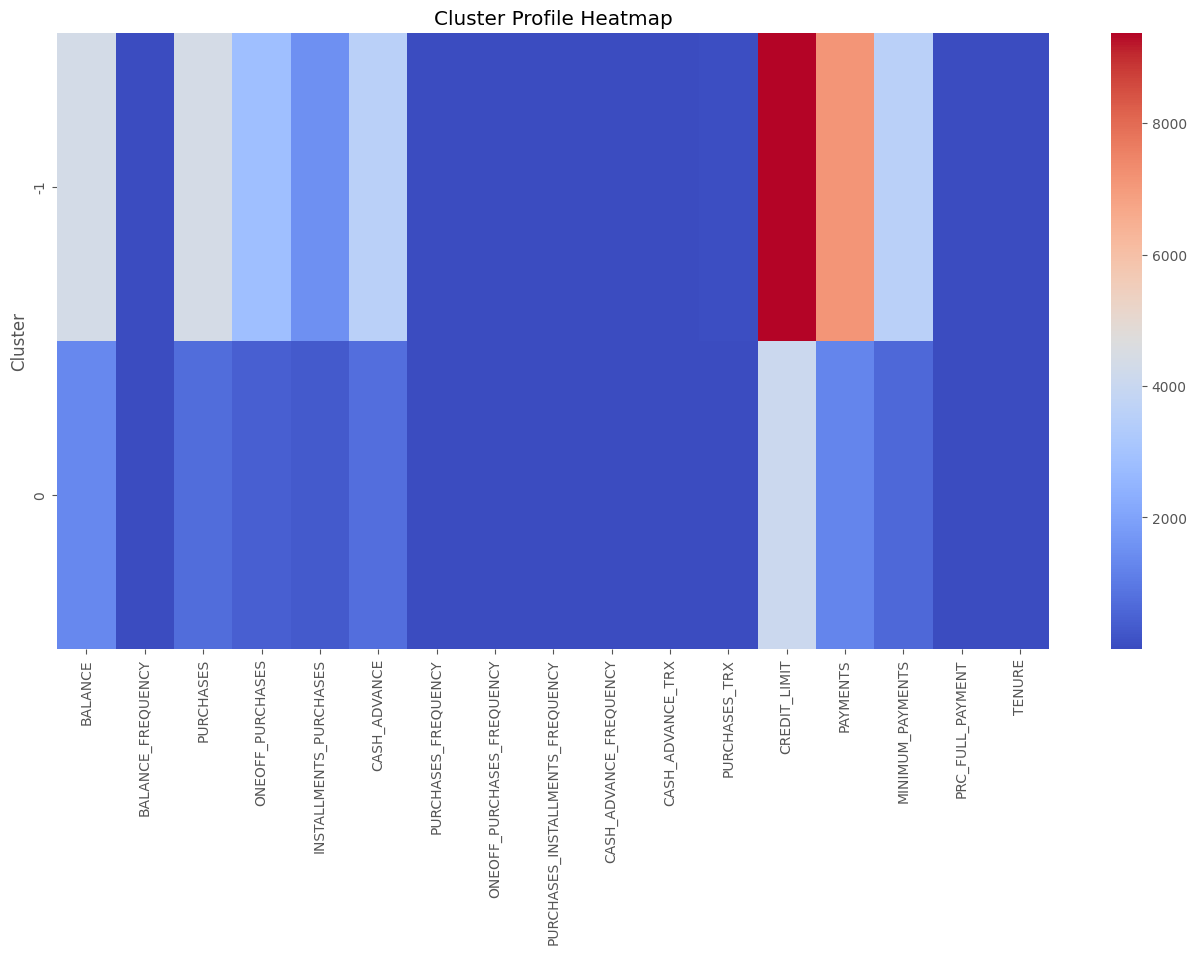

In [108]:

plt.figure(figsize=(16,8))

sns.heatmap(

    cluster_profile,

    cmap="coolwarm",

    annot=False

)

plt.title("Cluster Profile Heatmap")

plt.show()


Interpretation

* High-balance clusters.

* High-spending customer groups.

* Customers with frequent cash advances.

* Low-activity customer segments.

* Outlier behavior.
